# Qwen3.5-122B Reflexion: Cross-Run Comparison

Compare reflexion performance across 4 experiment runs:
1. **reflexion** (20260317) — 5 episodes, no init mode
2. **reflexion-rerun** (20260322) — 4 episodes, no init mode
3. **init-easy** (20260322) — 4 episodes, easy initial family prompt
4. **init-hard** (20260322) — 4 episodes, hard initial family prompt

Key questions:
- Do metrics improve across episodes (is reflexion working)?
- Does init difficulty affect reflexion benefit?
- Are reflections actionable — does behavior actually shift?

In [1]:
from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_colwidth', 200)
plt.style.use('default')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

In [2]:
# ── Experiment registry ───────────────────────────────────────────────────────
# Each entry: (label, path relative to notebooks/data/custom/)
DATA_ROOT = Path('data/custom')

EXPERIMENTS = {
    'reflexion': DATA_ROOT / (
        'qwen3dot5-122b-reflx-tracking/'
        'systems_ternary_n10_maxatoms20_intermetallic_smact/20260317-220021/'
        'llm_react_orchestrator_systems_ternary_n10_maxatoms20_intermetallic_smact'
        '_2systems_50queries_100stabilitymeV'
    ),
    'reflexion-rerun': DATA_ROOT / (
        'qwen3dot5-122b-reflx-tracking/'
        'systems_ternary_n10_maxatoms20_intermetallic_smact/20260322-204410/'
        'llm_react_orchestrator_systems_ternary_n10_maxatoms20_intermetallic_smact'
        '_2systems_50queries_100stabilitymeV'
    ),
    'init-easy': DATA_ROOT / (
        'qwen3dot5-122b-reflx-trackin_init_easy/'
        'systems_ternary_n10_maxatoms20_intermetallic_smact/20260322-204255/'
        'llm_react_orchestrator_systems_ternary_n10_maxatoms20_intermetallic_smact'
        '_2systems_50queries_100stabilitymeV'
    ),
    'init-hard': DATA_ROOT / (
        'qwen3dot5-122b-reflx-tracking_init_hard/'
        'systems_ternary_n10_maxatoms20_intermetallic_smact/20260322-204328/'
        'llm_react_orchestrator_systems_ternary_n10_maxatoms20_intermetallic_smact'
        '_2systems_50queries_100stabilitymeV'
    ),
}

for label, p in EXPERIMENTS.items():
    exists = p.exists()
    print(f'  {label:20s}  {"OK" if exists else "MISSING"}  {p}')

  reflexion             OK  data/custom/qwen3dot5-122b-reflx-tracking/systems_ternary_n10_maxatoms20_intermetallic_smact/20260317-220021/llm_react_orchestrator_systems_ternary_n10_maxatoms20_intermetallic_smact_2systems_50queries_100stabilitymeV
  reflexion-rerun       OK  data/custom/qwen3dot5-122b-reflx-tracking/systems_ternary_n10_maxatoms20_intermetallic_smact/20260322-204410/llm_react_orchestrator_systems_ternary_n10_maxatoms20_intermetallic_smact_2systems_50queries_100stabilitymeV
  init-easy             OK  data/custom/qwen3dot5-122b-reflx-trackin_init_easy/systems_ternary_n10_maxatoms20_intermetallic_smact/20260322-204255/llm_react_orchestrator_systems_ternary_n10_maxatoms20_intermetallic_smact_2systems_50queries_100stabilitymeV
  init-hard             OK  data/custom/qwen3dot5-122b-reflx-tracking_init_hard/systems_ternary_n10_maxatoms20_intermetallic_smact/20260322-204328/llm_react_orchestrator_systems_ternary_n10_maxatoms20_intermetallic_smact_2systems_50queries_100stabilitym

In [3]:
# ── Helpers ────────────────────────────────────────────────────────────────────
FORMULA_RE = re.compile(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)')

def parse_formula(formula: str) -> dict[str, float]:
    if not isinstance(formula, str) or not formula.strip():
        return {}
    parsed: dict[str, float] = {}
    for elem, raw in FORMULA_RE.findall(formula.replace(' ', '')):
        parsed[elem] = parsed.get(elem, 0.0) + (float(raw) if raw else 1.0)
    return parsed

def canonical_family(formula: str) -> str:
    comp = parse_formula(formula)
    return '-'.join(sorted(comp)) if comp else 'UNKNOWN'

def arity(formula: str) -> int:
    return len(parse_formula(formula))

def extract_episode_id(path: Path) -> int:
    m = re.search(r'episode_(\d+)', path.stem)
    return int(m.group(1)) if m else -1

In [4]:
# ── Load all runs into unified DataFrames ─────────────────────────────────────

def load_episode_summaries(run_dir: Path) -> list[dict]:
    rows = []
    for sys_dir in sorted((run_dir / 'systems').iterdir()):
        if not sys_dir.is_dir():
            continue
        p = sys_dir / 'summary' / 'episodes.json'
        if not p.exists():
            continue
        for item in json.loads(p.read_text()):
            rows.append({'system': sys_dir.name, **item})
    return rows

def load_trajectory_steps(run_dir: Path) -> list[dict]:
    rows = []
    for sys_dir in sorted((run_dir / 'systems').iterdir()):
        if not sys_dir.is_dir():
            continue
        for traj_file in sorted((sys_dir / 'trajectories').glob('episode_*.json')):
            payload = json.loads(traj_file.read_text())
            ep_id = extract_episode_id(traj_file)
            for q_idx, step in enumerate(payload.get('trajectory', [])):
                rf = step.get('reduced_formula', '')
                rows.append({
                    'system': sys_dir.name,
                    'episode': ep_id,
                    'step': q_idx,
                    'reduced_formula': rf,
                    'family': canonical_family(rf),
                    'arity': arity(rf),
                    'e_above_hull': step.get('e_above_hull'),
                    'is_stable': bool(step.get('is_stable', False)),
                    'is_newly_discovered': bool(step.get('is_newly_discovered', False)),
                    'formation_energy_per_atom': step.get('formation_energy_per_atom'),
                })
    return rows

def load_reflections(run_dir: Path) -> list[dict]:
    rows = []
    refl_root = run_dir / 'reflections'
    if not refl_root.exists():
        return rows
    for sys_dir in sorted(refl_root.iterdir()):
        if not sys_dir.is_dir():
            continue
        f = sys_dir / 'reflections.json'
        if not f.exists():
            continue
        data = json.loads(f.read_text())
        for i, item in enumerate(data):
            text = item if isinstance(item, str) else item.get('reflection', str(item))
            rows.append({'system': sys_dir.name, 'after_episode': i, 'reflection': text})
    return rows

# Build unified DataFrames
all_episodes, all_steps, all_reflections = [], [], []

for label, run_dir in EXPERIMENTS.items():
    if not run_dir.exists():
        print(f'SKIPPING {label} — path not found')
        continue
    for row in load_episode_summaries(run_dir):
        row['run'] = label
        all_episodes.append(row)
    for row in load_trajectory_steps(run_dir):
        row['run'] = label
        all_steps.append(row)
    for row in load_reflections(run_dir):
        row['run'] = label
        all_reflections.append(row)

df_ep = pd.DataFrame(all_episodes)
df_steps = pd.DataFrame(all_steps)
df_refl = pd.DataFrame(all_reflections)

print(f'Episode summaries: {len(df_ep):,}  |  Steps: {len(df_steps):,}  |  Reflections: {len(df_refl):,}')
print(f'Runs loaded: {sorted(df_ep["run"].unique())}')
df_ep.groupby('run')[['system', 'episode_id']].nunique()

Episode summaries: 34  |  Steps: 1,700  |  Reflections: 24
Runs loaded: ['init-easy', 'init-hard', 'reflexion', 'reflexion-rerun']


,system,episode_id
run,,
init-easy,2,4
init-hard,2,4
reflexion,2,5
reflexion-rerun,2,4


## 1. Episode-over-Episode Progress

The central question: do key metrics **improve** across episodes within each run?
If reflexion works, later episodes should show higher stable discovery counts,
better hull fractions, and lower mean e_above_hull.

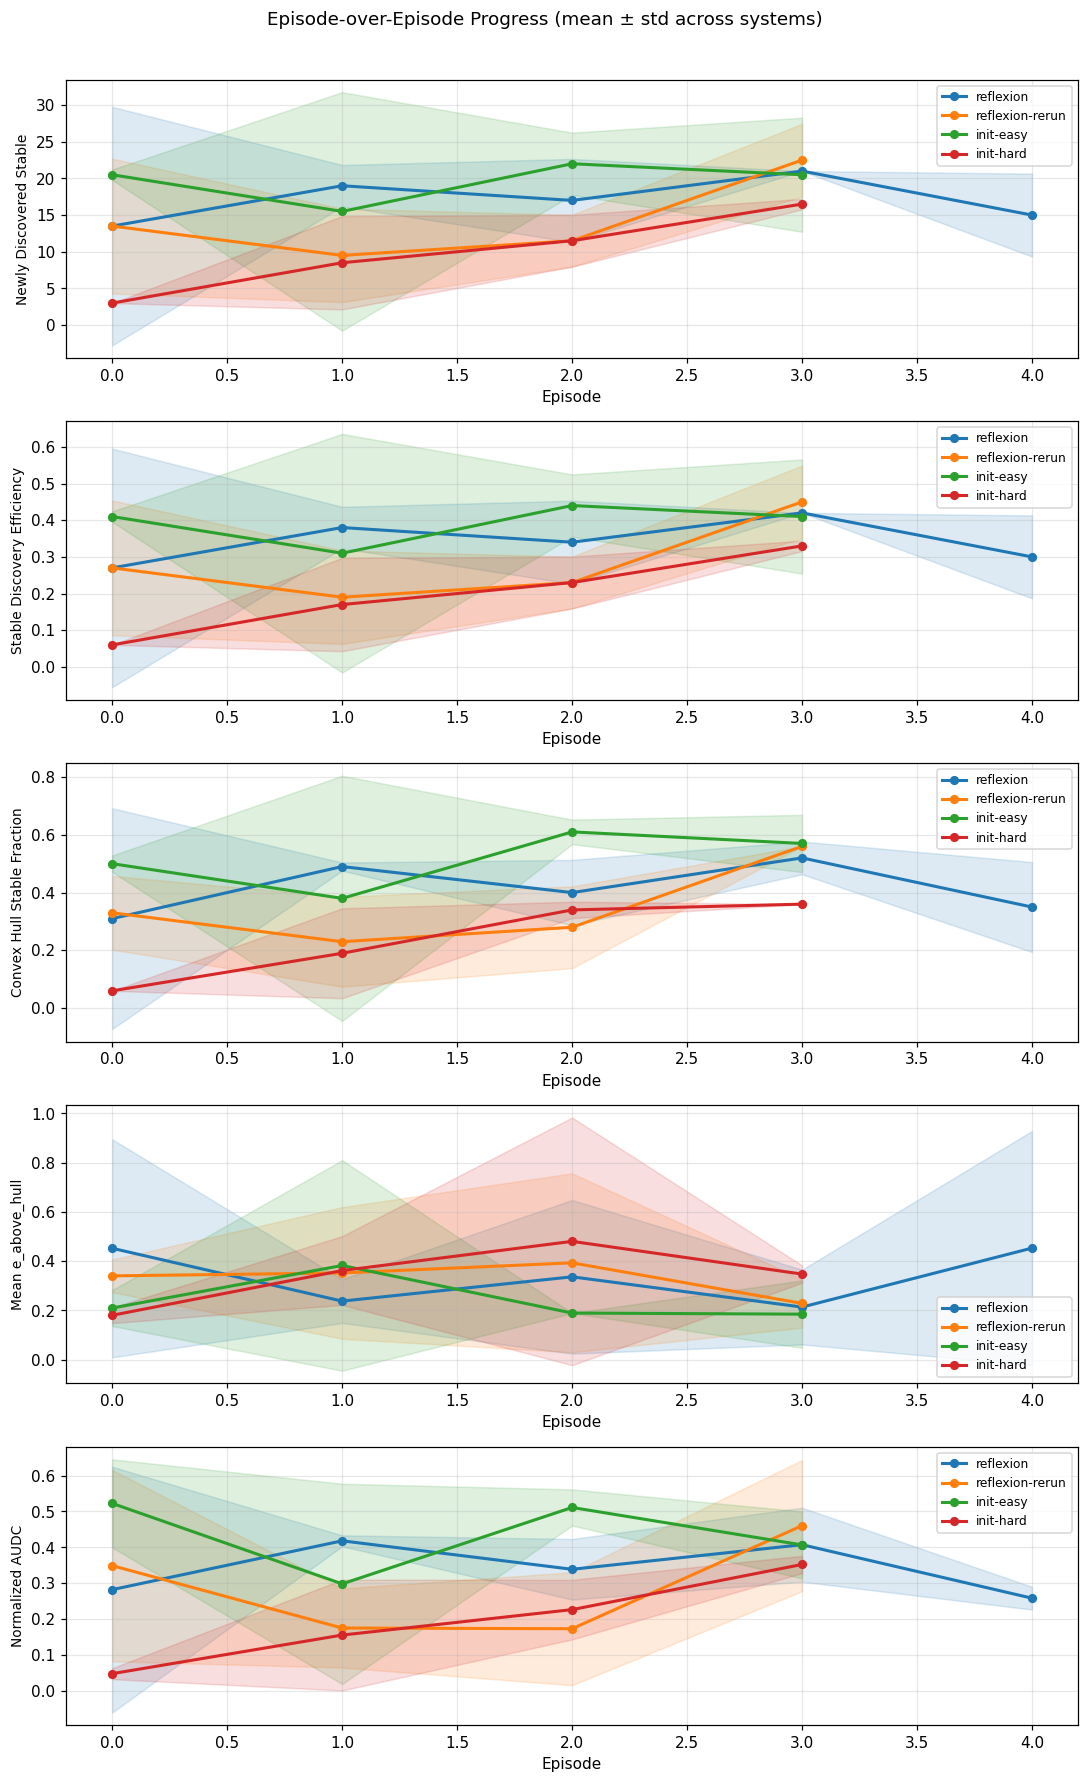

In [5]:
# ── Key metrics per episode, averaged across systems ──────────────────────────
PROGRESS_METRICS = [
    ('final/num_newly_discovered_stable', 'Newly Discovered Stable'),
    ('final/stable_discovery_efficiency', 'Stable Discovery Efficiency'),
    ('final/convex_hull_stable_fraction', 'Convex Hull Stable Fraction'),
    ('final/convex_hull_e_above_hull_mean', 'Mean e_above_hull'),
    ('final/discovery_curve_area_under_discovery_curve_normalized', 'Normalized AUDC'),
]

fig, axes = plt.subplots(len(PROGRESS_METRICS), 1, figsize=(10, 3.2 * len(PROGRESS_METRICS)),
                          sharex=False)
run_colors = {r: c for r, c in zip(EXPERIMENTS, ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])}

for ax, (col, title) in zip(axes, PROGRESS_METRICS):
    for run_label in EXPERIMENTS:
        sub = df_ep[df_ep['run'] == run_label]
        if col not in sub.columns:
            continue
        agg = sub.groupby('episode_id')[col].agg(['mean', 'std']).reset_index()
        ax.plot(agg['episode_id'], agg['mean'], 'o-', label=run_label,
                color=run_colors[run_label], linewidth=2, markersize=5)
        ax.fill_between(agg['episode_id'],
                        agg['mean'] - agg['std'],
                        agg['mean'] + agg['std'],
                        alpha=0.15, color=run_colors[run_label])
    ax.set_ylabel(title, fontsize=9)
    ax.set_xlabel('Episode')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Episode-over-Episode Progress (mean ± std across systems)', fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

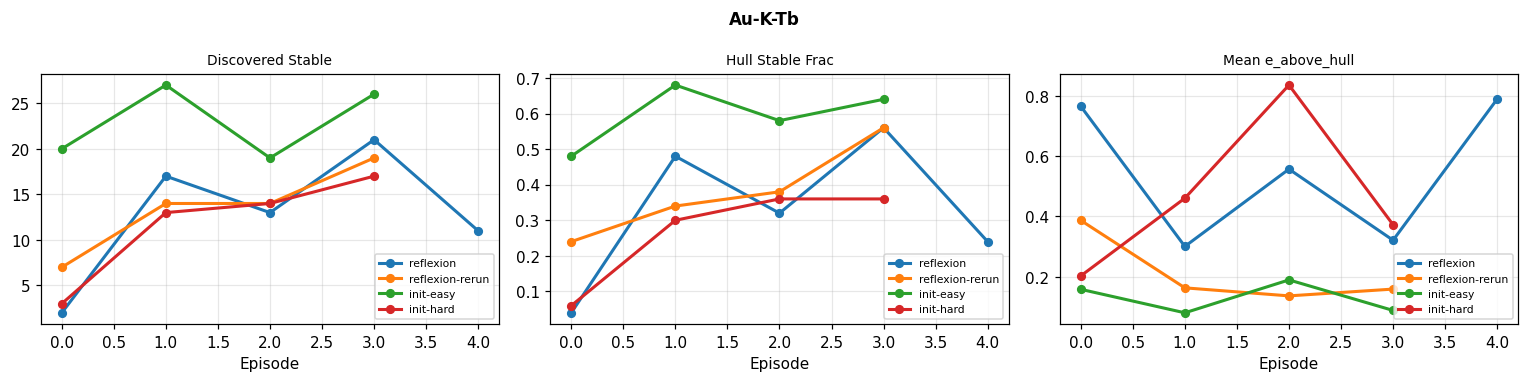

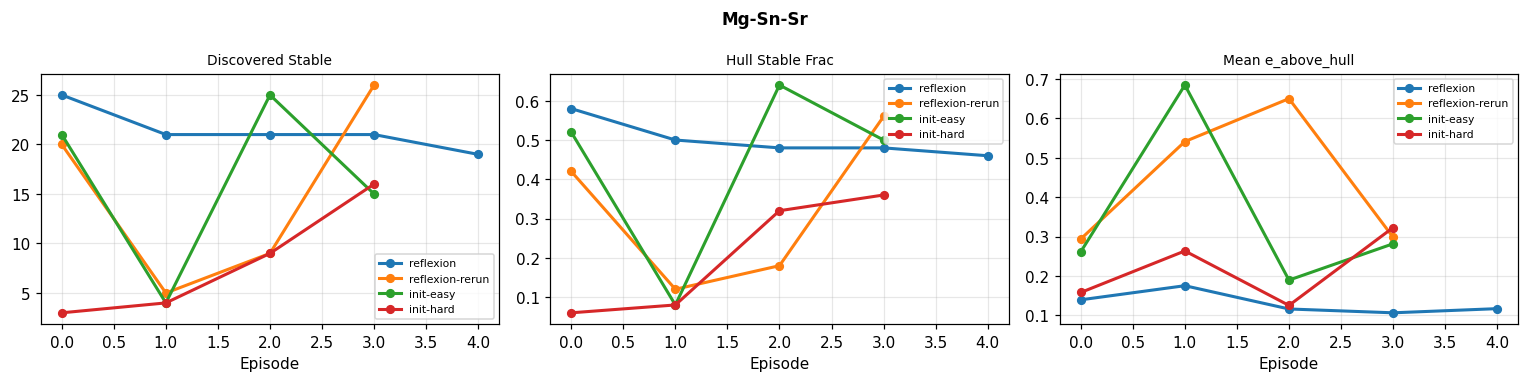

In [6]:
# ── Same view but per-system (not averaged) ──────────────────────────────────
systems = sorted(df_ep['system'].unique())

for system in systems:
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    fig.suptitle(f'{system}', fontsize=11, fontweight='bold')
    metric_subset = [
        ('final/num_newly_discovered_stable', 'Discovered Stable'),
        ('final/convex_hull_stable_fraction', 'Hull Stable Frac'),
        ('final/convex_hull_e_above_hull_mean', 'Mean e_above_hull'),
    ]
    for ax, (col, title) in zip(axes, metric_subset):
        for run_label in EXPERIMENTS:
            sub = df_ep[(df_ep['run'] == run_label) & (df_ep['system'] == system)]
            if col not in sub.columns or sub.empty:
                continue
            ax.plot(sub['episode_id'], sub[col], 'o-', label=run_label,
                    color=run_colors[run_label], linewidth=2, markersize=5)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('Episode')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

## 2. Final Metrics Comparison

Compare the best (last) episode metrics across runs. Also show first-episode
vs last-episode delta to quantify how much each run improved.

In [7]:
# ── First vs Last episode comparison ──────────────────────────────────────────
COMPARE_METRICS = [
    'final/num_newly_discovered_stable',
    'final/stable_discovery_efficiency',
    'final/convex_hull_stable_fraction',
    'final/convex_hull_e_above_hull_mean',
    'final/discovery_curve_area_under_discovery_curve_normalized',
]

rows = []
for run_label in EXPERIMENTS:
    sub = df_ep[df_ep['run'] == run_label]
    if sub.empty:
        continue
    first_ep = sub['episode_id'].min()
    last_ep = sub['episode_id'].max()
    first = sub[sub['episode_id'] == first_ep][COMPARE_METRICS].mean()
    last = sub[sub['episode_id'] == last_ep][COMPARE_METRICS].mean()
    delta = last - first
    for col in COMPARE_METRICS:
        short = col.split('/')[-1]
        rows.append({
            'run': run_label,
            'metric': short,
            'first_episode': round(first[col], 4),
            'last_episode': round(last[col], 4),
            'delta': round(delta[col], 4),
            'pct_change': round(delta[col] / (abs(first[col]) + 1e-9) * 100, 1),
        })

df_compare = pd.DataFrame(rows)
display(df_compare.pivot_table(index='metric', columns='run',
                                values=['first_episode', 'last_episode', 'delta'],
                                aggfunc='first')
        .swaplevel(axis=1).sort_index(axis=1))

run                                                   init-easy                \
                                                          delta first_episode   
metric                                                                          
convex_hull_e_above_hull_mean                           -0.0249        0.2098   
convex_hull_stable_fraction                              0.0700        0.5000   
discovery_curve_area_under_discovery_curve_normalized   -0.1156        0.5226   
num_newly_discovered_stable                              0.0000       20.5000   
stable_discovery_efficiency                              0.0000        0.4100   

run                                                                init-hard  \
                                                      last_episode     delta   
metric                                                                         
convex_hull_e_above_hull_mean                               0.1849    0.1674   
convex_hull_stable_fraction                                 0.5700    0.3000   
discovery_curve_area_under_discovery_curve_normalized       0.4070    0.3038   
num_newly_discovered_stable                                20.5000   13.5000   
stable_discovery_efficiency                                 0.4100    0.2700   

run                                                                  \
                                                      first_episode   
metric                                                                
convex_hull_e_above_hull_mean                                0.1803   
convex_hull_stable_fraction                                  0.0600   
discovery_curve_area_under_discovery_curve_normalized        0.0488   
num_newly_discovered_stable                                  3.0000   
stable_discovery_efficiency                                  0.0600   

run                                                                reflexion  \
                                                      last_episode     delta   
metric                                                                         
convex_hull_e_above_hull_mean                               0.3477    0.0008   
convex_hull_stable_fraction                                 0.3600    0.0400   
discovery_curve_area_under_discovery_curve_normalized       0.3526   -0.0238   
num_newly_discovered_stable                                16.5000    1.5000   
stable_discovery_efficiency                                 0.3300    0.0300   

run                                                                  \
                                                      first_episode   
metric                                                                
convex_hull_e_above_hull_mean                                0.4525   
convex_hull_stable_fraction                                  0.3100   
discovery_curve_area_under_discovery_curve_normalized        0.2826   
num_newly_discovered_stable                                 13.5000   
stable_discovery_efficiency                                  0.2700   

run                                                                 \
                                                      last_episode   
metric                                                               
convex_hull_e_above_hull_mean                               0.4532   
convex_hull_stable_fraction                                 0.3500   
discovery_curve_area_under_discovery_curve_normalized       0.2588   
num_newly_discovered_stable                                15.0000   
stable_discovery_efficiency                                 0.3000   

run                                                   reflexion-rerun  \
                                                                delta   
metric                                                                  
convex_hull_e_above_hull_mean                                 -0.1118   
convex_hull_stable_fraction                                    0.2300   
disco

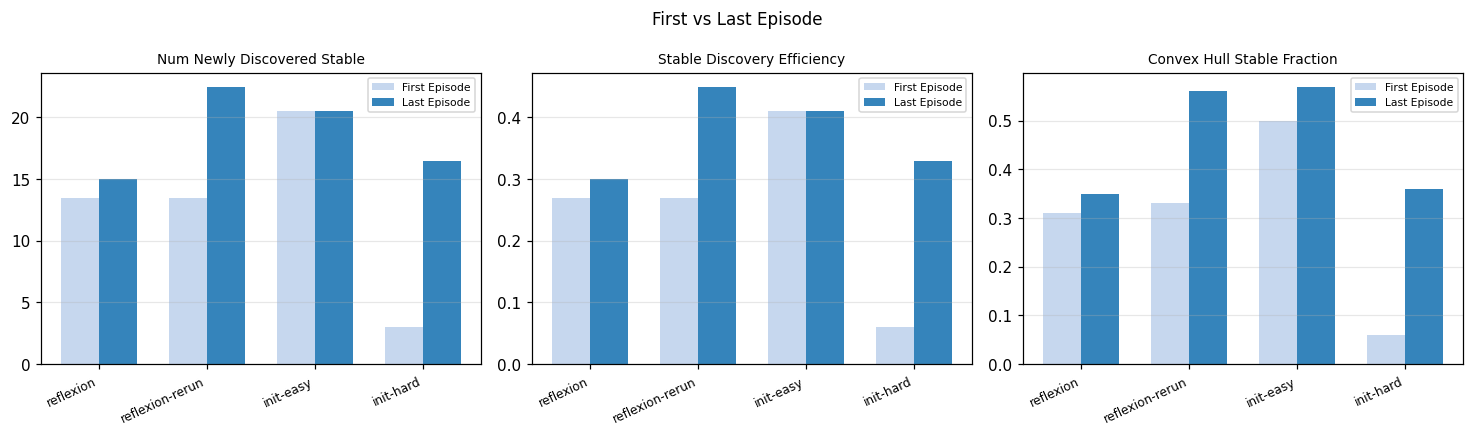

In [8]:
# ── Bar chart: first vs last episode delta ────────────────────────────────────
plot_metrics = ['num_newly_discovered_stable', 'stable_discovery_efficiency',
                'convex_hull_stable_fraction']
runs = list(EXPERIMENTS.keys())

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4.5 * len(plot_metrics), 4))
for ax, metric in zip(axes, plot_metrics):
    sub = df_compare[df_compare['metric'] == metric]
    x = np.arange(len(runs))
    w = 0.35
    first_vals = [sub[sub['run'] == r]['first_episode'].values[0] if r in sub['run'].values else 0 for r in runs]
    last_vals = [sub[sub['run'] == r]['last_episode'].values[0] if r in sub['run'].values else 0 for r in runs]
    ax.bar(x - w/2, first_vals, w, label='First Episode', alpha=0.7, color='#aec7e8')
    ax.bar(x + w/2, last_vals, w, label='Last Episode', alpha=0.9, color='#1f77b4')
    ax.set_xticks(x)
    ax.set_xticklabels(runs, rotation=25, ha='right', fontsize=8)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('First vs Last Episode', fontsize=11)
fig.tight_layout()
plt.show()

## 3. Step-Level Behavior Across Episodes

Does the agent's behavior actually change episode-to-episode?
We look at per-episode stability rate, composition diversity,
and family concentration to see if reflexion shifts strategy.

In [9]:
# ── Per-episode behavior aggregates from step data ────────────────────────────
ep_behavior = (
    df_steps.groupby(['run', 'system', 'episode'])
    .agg(
        stable_rate=('is_stable', 'mean'),
        discovery_rate=('is_newly_discovered', 'mean'),
        mean_e_above_hull=('e_above_hull', 'mean'),
        unique_families=('family', 'nunique'),
        unique_formulas=('reduced_formula', 'nunique'),
        total_steps=('step', 'count'),
    )
    .reset_index()
)

# Top-family concentration: share of queries going to the most-used family
top_fam_share = (
    df_steps.groupby(['run', 'system', 'episode', 'family'])
    .size()
    .rename('count')
    .reset_index()
)
top_fam_share['share'] = top_fam_share.groupby(['run', 'system', 'episode'])['count'].transform(
    lambda x: x / x.sum()
)
top_conc = (
    top_fam_share
    .sort_values('share', ascending=False)
    .groupby(['run', 'system', 'episode'])
    .first()
    .reset_index()
    .rename(columns={'family': 'top_family', 'share': 'top_family_share'})
    [['run', 'system', 'episode', 'top_family', 'top_family_share']]
)

ep_behavior = ep_behavior.merge(top_conc, on=['run', 'system', 'episode'], how='left')
ep_behavior.head()

,run,system,episode,stable_rate,discovery_rate,mean_e_above_hull,unique_families,unique_formulas,total_steps,top_family,top_family_share
0,init-easy,Au-K-Tb,0,0.48,0.90,0.158187,3,15,50,Au-Tb,0.82
1,init-easy,Au-K-Tb,1,0.68,0.82,0.080060,3,16,50,Au-Tb,0.90
2,init-easy,Au-K-Tb,2,0.58,0.74,0.189309,2,15,50,Au-Tb,0.98
3,init-easy,Au-K-Tb,3,0.64,0.86,0.088022,1,17,50,Au-Tb,1.00
4,init-easy,Mg-Sn-Sr,0,0.52,0.90,0.261258,4,20,50,Mg-Sn-Sr,0.80


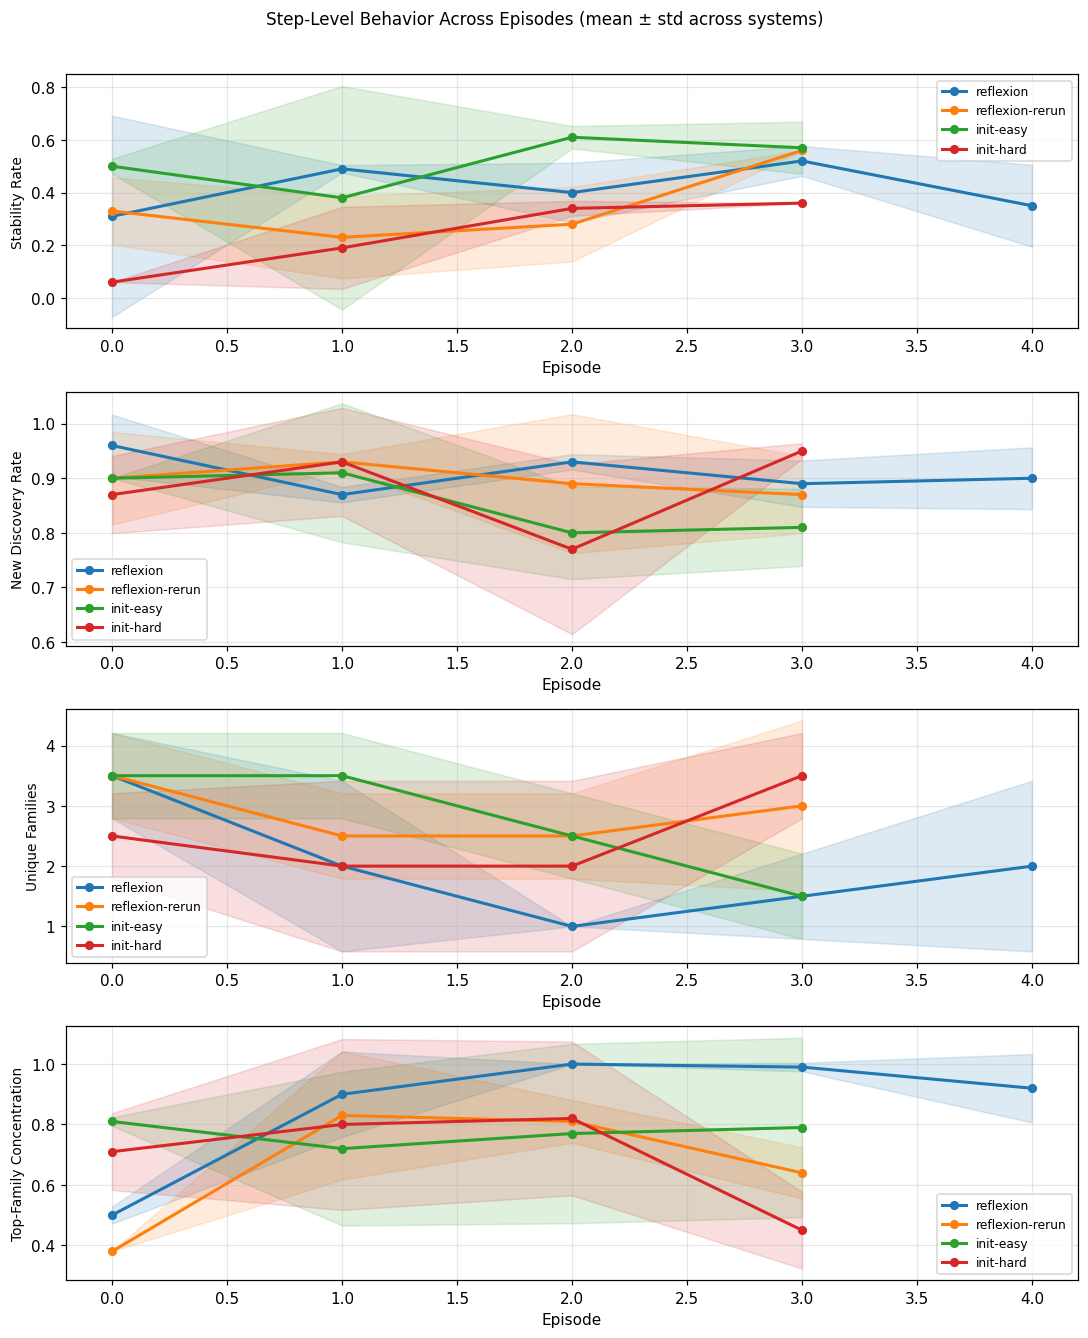

In [10]:
# ── Plot behavior metrics across episodes ─────────────────────────────────────
behavior_metrics = [
    ('stable_rate', 'Stability Rate'),
    ('discovery_rate', 'New Discovery Rate'),
    ('unique_families', 'Unique Families'),
    ('top_family_share', 'Top-Family Concentration'),
]

fig, axes = plt.subplots(len(behavior_metrics), 1, figsize=(10, 3 * len(behavior_metrics)))
for ax, (col, title) in zip(axes, behavior_metrics):
    for run_label in EXPERIMENTS:
        sub = ep_behavior[ep_behavior['run'] == run_label]
        if sub.empty:
            continue
        agg = sub.groupby('episode')[col].agg(['mean', 'std']).reset_index()
        ax.plot(agg['episode'], agg['mean'], 'o-', label=run_label,
                color=run_colors[run_label], linewidth=2, markersize=5)
        ax.fill_between(agg['episode'],
                        agg['mean'] - agg['std'],
                        agg['mean'] + agg['std'],
                        alpha=0.15, color=run_colors[run_label])
    ax.set_ylabel(title, fontsize=9)
    ax.set_xlabel('Episode')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Step-Level Behavior Across Episodes (mean ± std across systems)', fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

## 4. Family Reallocation: Learning from Mistakes?

If reflexion works, families with poor stability in episode *t* should get
fewer queries in episode *t+1*. We compute per-family share shifts and
correlate them with prior-episode stability.

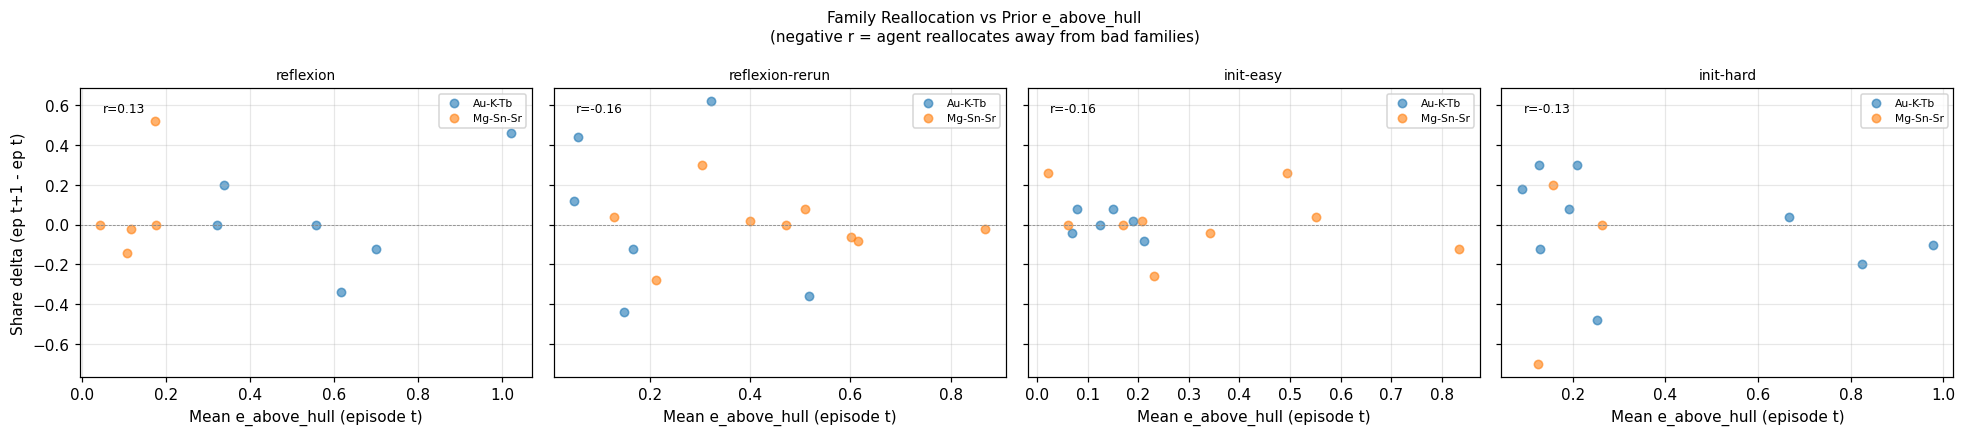

In [11]:
# ── Family share and stability per episode ────────────────────────────────────
fam_stats = (
    df_steps.groupby(['run', 'system', 'episode', 'family'])
    .agg(queries=('step', 'count'), mean_ehull=('e_above_hull', 'mean'),
         stable_count=('is_stable', 'sum'))
    .reset_index()
)
fam_stats['share'] = fam_stats.groupby(['run', 'system', 'episode'])['queries'].transform(
    lambda x: x / x.sum()
)
fam_stats['stable_rate'] = fam_stats['stable_count'] / fam_stats['queries']

# Compute shift: share in episode t+1 minus share in episode t
fam_stats = fam_stats.sort_values(['run', 'system', 'family', 'episode'])
fam_next = fam_stats.copy()
fam_next['episode'] = fam_next['episode'] - 1  # align t+1 with t
fam_next = fam_next.rename(columns={'share': 'next_share', 'stable_rate': 'next_stable_rate'})

fam_shift = fam_stats.merge(
    fam_next[['run', 'system', 'episode', 'family', 'next_share']],
    on=['run', 'system', 'episode', 'family'],
    how='inner'
)
fam_shift['share_delta'] = fam_shift['next_share'] - fam_shift['share']

# Plot: prior stable_rate vs share_delta (negative correlation = learning)
fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(4.5 * len(EXPERIMENTS), 4),
                          sharey=True)
if not hasattr(axes, '__len__'):
    axes = [axes]

for ax, run_label in zip(axes, EXPERIMENTS):
    sub = fam_shift[fam_shift['run'] == run_label]
    if sub.empty:
        continue
    # Color by system
    for system in sub['system'].unique():
        ss = sub[sub['system'] == system]
        ax.scatter(ss['mean_ehull'], ss['share_delta'], alpha=0.6, s=30, label=system)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Mean e_above_hull (episode t)')
    ax.set_title(run_label, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    # Correlation
    if len(sub) > 3:
        corr = sub[['mean_ehull', 'share_delta']].corr().iloc[0, 1]
        ax.text(0.05, 0.95, f'r={corr:.2f}', transform=ax.transAxes, fontsize=8, va='top')

axes[0].set_ylabel('Share delta (ep t+1 - ep t)')
fig.suptitle('Family Reallocation vs Prior e_above_hull\n(negative r = agent reallocates away from bad families)',
             fontsize=10)
fig.tight_layout()
plt.show()

## 5. Reflection Content Analysis

What are the reflections actually saying? Do they get more specific over time?
Are there recurring themes (e.g., "reduce K", "focus on binaries")?

In [12]:
# ── Display all reflections grouped by run and system ─────────────────────────
for run_label in EXPERIMENTS:
    sub = df_refl[df_refl['run'] == run_label].sort_values(['system', 'after_episode'])
    if sub.empty:
        display(Markdown(f'### {run_label}\n*No reflections found.*'))
        continue
    display(Markdown(f'### {run_label} ({len(sub)} reflections)'))
    for _, row in sub.iterrows():
        display(Markdown(
            f"**{row['system']} — after episode {row['after_episode']}**\n\n"
            f"{row['reflection'][:600]}{'...' if len(str(row['reflection'])) > 600 else ''}"
        ))

### reflexion (6 reflections)

**Au-K-Tb — after episode 0**

on ## ]]
        {reflection}

**Au-K-Tb — after episode 1**

*   **Enforce Stoichiometry Uniqueness:** Implement a hard limit of one query per unique stoichiometry (e.g., Au5Tb1). If the first structure for a ratio exceeds 0.05 eV/atom, discard the ratio immediately rather than retrying with different structures.
*   **Prioritize Known Phases for Recall:** Dedicate the first 20% of the query budget to explicitly generating and evaluating known Au-Tb intermetallics from literature (e.g., AuTb, Au3Tb) to guarantee a non-zero recall score before exploring novel compositions.
*   **Restrict Unit Cell Size:** Limit structure generation to cells with ≤ 8 site...

**Au-K-Tb — after episode 2**

*   **Fix Stability Counting Threshold**: Ensure structures with e_above_hull < 0.05 eV/atom are counted as stable; the episode found 3 such structures (#3, #11, #15) but outcome reported 0. Verify oracle threshold alignment.
*   **Limit Stoichiometry Redundancy**: Cap queries per unique stoichiometry at 3 attempts. If all exceed 0.1 eV/atom, abandon that ratio rather than continuing (e.g., Au2Tb1 was queried 6 times with 1 success).
*   **Prioritize Proven Ratios**: Concentrate 60%+ of queries on Au4Tb1 and Au2Tb1 ratios which produced stable structures, rather than exploring low-yield compos...

**Mg-Sn-Sr — after episode 0**

*   **Implement Hard Deduplication Constraints:** Enforce a system-level limit of 2 queries per unique stoichiometry to prevent fixation on ratios like `Sr2MgSn4` and force broader chemical space coverage.
*   **Enforce Strict Energy Filtering:** Discard any candidate with predicted `e_above_hull` > 0.05 eV/atom before oracle submission to eliminate the >50% of queries wasted on unstable structures.
*   **Diversify Composition Sampling:** Utilize temperature-scaled sampling to prioritize under-explored Mg-rich and Sr-rich compositions, moving away from the over-sampled 1:2:1 clusters.
*   **Pr...

...

**Au-K-Tb — after episode 1**

• **Resolve tracking discrepancy immediately**: Verify whether "novel stable" structures in trajectory match the "known stable phases" used for recall calculation; this 14 vs 0 gap must be understood before measuring success.

• **Enforce strict duplicate prevention**: Implement a query log that blocks re-evaluation of any composition already queried; Au1 Tb1 alone consumed 10 queries that could have explored 10 new candidates.

• **Apply 2-query hard stop per composition**: After 2 unsuccessful queries on any composition, deprioritize immediately; Au1 K1 Tb1 and Au1 K2 Tb1 each wasted 4+ quer...

**Au-K-Tb — after episode 2**

• **Resolve tracking discrepancy immediately**: The 17 novel+stable in trajectory vs. 0 in outcome must be investigated—verify whether discovered structures match the "known stable phases" definition used for recall calculation before measuring success.

• **Enforce strict duplicate prevention with query log**: Block re-querying any composition already evaluated; ~30 queries were wasted on repeats (Au3 Tb1, Au2 Tb1, Au5 K1, Au3 K2) that could have explored new candidates.

• **Apply 2-query hard stop per composition**: After 2 unsuccessful queries on any composition, deprioritize immediately; ...

**Mg-Sn-Sr — after episode 0**

• **Exploit immediately after discovery**: When any stable structure is found, generate 3-5 similar compositions (±1 atom in Mg/Sr ratios) before querying new families—this was missed after queries 29, 36, 38, 40.

• **Enforce early stopping on poor performers**: Abandon composition families after 3 consecutive queries with e_above_hull > 0.15 eV; Mg2Sn1Sr3 consumed 10 queries with zero stability.

• **Concentrate 70% of queries on proven families**: Focus on Mg3Sn1Sr2 and Mg2Sn1Sr2 (both showed stability); reduce exploration of unproductive families like Mg1Sn1Sr3 and Mg2Sn1Sr3.

• **Limit bi...

**Mg-Sn-Sr — after episode 1**

• **Mandate Known Phase Verification**: 0% recall indicates a total miss of the known convex hull. The first 15 queries in the next episode must explicitly target compositions documented in the Materials Project/ICSD for Mg-Sn-Sr to establish baseline recall before exploring novelty.

• **Enforce Ground State Criteria**: The trajectory accepted e_above_hull > 0 as "stable," but the outcome counted 0. Prioritize structure generation methods that target the global minimum (e=0.000) rather than accepting metastable states (e.g., 0.057 eV) as successful discoveries.

• **Implement Hard Query Caps*...

**Mg-Sn-Sr — after episode 2**

*   **Enforce Known Phase Priority:** 0% recall persists despite prior warnings. Dedicate the first 15 queries strictly to known Materials Project/ICSD compositions for Mg-Sn-Sr to ensure baseline recall before novelty exploration.
*   **Align Stability Thresholds:** The agent flagged e=0.06 eV as stable but the outcome counted 0. Raise the stability bar to e < 0.02 eV to prevent wasting queries on metastable states.
*   **Mandate Exploitation on Ground States:** Query 45 found e=0.000 but generated no follow-ups. Implement a hard rule: upon finding e < 0.01 eV, immediately query 3-5 structura...

In [13]:
# ── Reflection statistics: length and keyword signals ─────────────────────────
if not df_refl.empty:
    df_refl['length'] = df_refl['reflection'].str.len()
    df_refl['n_bullet_points'] = df_refl['reflection'].str.count(r'^\s*[-*]', flags=re.MULTILINE)

    # Simple keyword extraction: elements, "binary"/"ternary", "reduce"/"increase"/"focus"/"avoid"
    for kw in ['reduce', 'avoid', 'focus', 'increase', 'prioritize', 'eliminate', 'binary', 'ternary']:
        df_refl[f'mentions_{kw}'] = df_refl['reflection'].str.lower().str.contains(kw, na=False)

    kw_cols = [c for c in df_refl.columns if c.startswith('mentions_')]
    display(Markdown('**Keyword frequency across all reflections:**'))
    display(df_refl.groupby('run')[kw_cols].sum().astype(int))

    display(Markdown('**Reflection length over time:**'))
    display(df_refl.groupby(['run', 'after_episode'])['length'].mean().unstack(0).round(0))

**Keyword frequency across all reflections:**

,mentions_reduce,mentions_avoid,mentions_focus,mentions_increase,mentions_prioritize,mentions_eliminate,mentions_binary,mentions_ternary
run,,,,,,,,
init-easy,0,3,4,0,6,0,4,4
init-hard,1,0,5,0,5,0,5,0
reflexion,1,1,1,0,4,2,1,1
reflexion-rerun,2,4,2,2,5,1,3,2


**Reflection length over time:**

run,init-easy,init-hard,reflexion,reflexion-rerun
after_episode,,,,
0,882.0,1008.0,402.0,754.0
1,916.0,1096.0,904.0,803.0
2,988.0,936.0,914.0,908.0


## 6. Init Difficulty: Easy vs Hard

Direct comparison of the easy-init and hard-init runs.
Does starting with a poor initial family prompt hurt or help long-term learning?

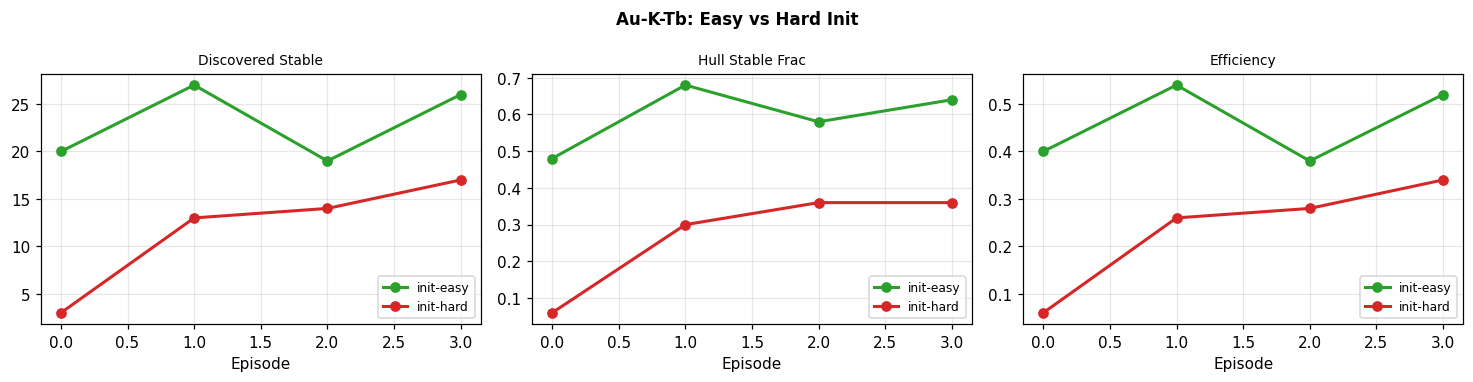

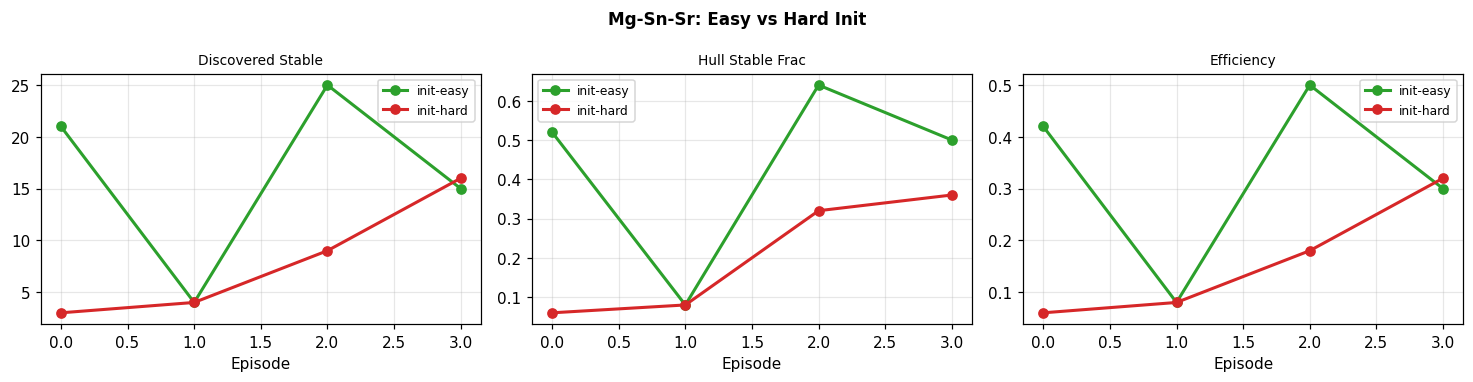

In [14]:
# ── Init-easy vs init-hard: episode trajectories side by side ─────────────────
init_runs = ['init-easy', 'init-hard']
init_metrics = [
    ('final/num_newly_discovered_stable', 'Discovered Stable'),
    ('final/convex_hull_stable_fraction', 'Hull Stable Frac'),
    ('final/stable_discovery_efficiency', 'Efficiency'),
]

for system in systems:
    fig, axes = plt.subplots(1, len(init_metrics), figsize=(4.5 * len(init_metrics), 3.5))
    fig.suptitle(f'{system}: Easy vs Hard Init', fontsize=11, fontweight='bold')
    for ax, (col, title) in zip(axes, init_metrics):
        for run_label in init_runs:
            sub = df_ep[(df_ep['run'] == run_label) & (df_ep['system'] == system)]
            if col not in sub.columns or sub.empty:
                continue
            ax.plot(sub['episode_id'], sub[col], 'o-', label=run_label,
                    color=run_colors[run_label], linewidth=2, markersize=6)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('Episode')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

In [15]:
# ── Init difficulty: does the gap close over episodes? ────────────────────────
# Compute delta between init-easy and init-hard per system per episode
init_compare = df_ep[df_ep['run'].isin(init_runs)].copy()
init_pivot = init_compare.pivot_table(
    index=['system', 'episode_id'],
    columns='run',
    values='final/num_newly_discovered_stable',
)
if 'init-easy' in init_pivot.columns and 'init-hard' in init_pivot.columns:
    init_pivot['gap'] = init_pivot['init-easy'] - init_pivot['init-hard']
    display(Markdown('**Easy minus Hard: newly discovered stable (positive = easy wins)**'))
    display(init_pivot.reset_index())
else:
    print('One of the init runs is missing data.')

**Easy minus Hard: newly discovered stable (positive = easy wins)**

run,system,episode_id,init-easy,init-hard,gap
0,Au-K-Tb,0,20.0,3.0,17.0
1,Au-K-Tb,1,27.0,13.0,14.0
2,Au-K-Tb,2,19.0,14.0,5.0
3,Au-K-Tb,3,26.0,17.0,9.0
4,Mg-Sn-Sr,0,21.0,3.0,18.0
5,Mg-Sn-Sr,1,4.0,4.0,0.0
6,Mg-Sn-Sr,2,25.0,9.0,16.0
7,Mg-Sn-Sr,3,15.0,16.0,-1.0


## 7. Cumulative Discovery Curves (Within-Episode)

Step-by-step cumulative discoveries within each episode, overlaid by run.
Shows whether later episodes find stable phases faster (steeper curves).

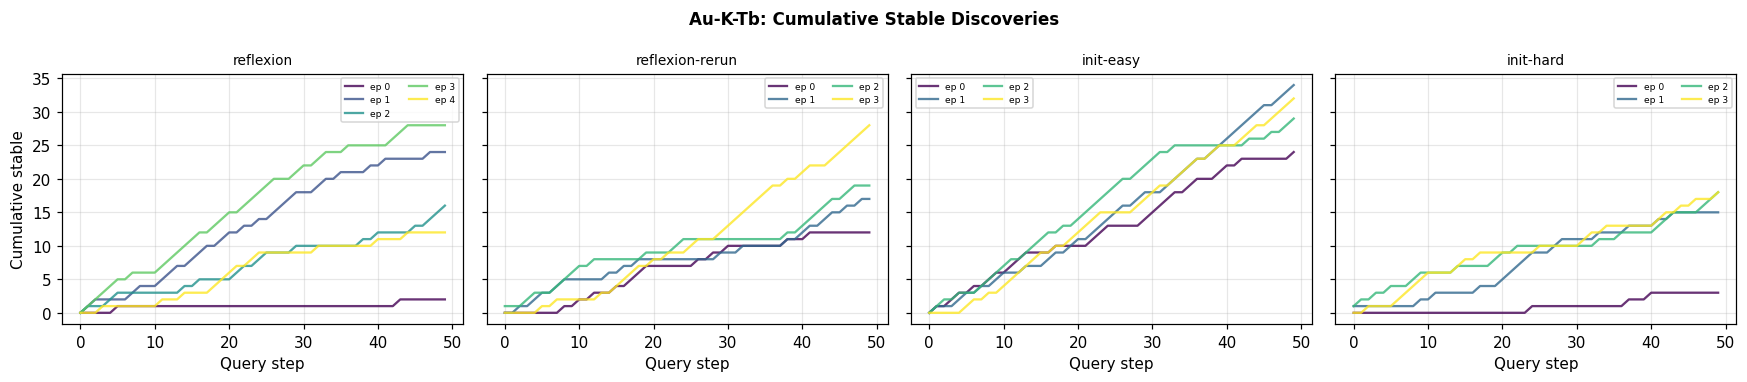

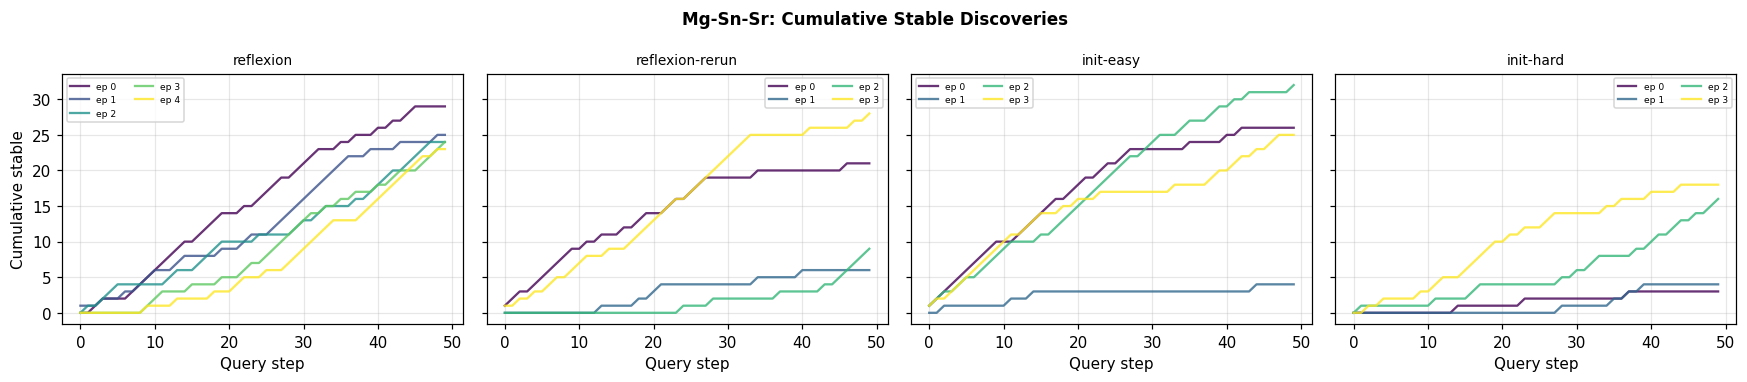

In [16]:
# ── Cumulative stable discoveries within each episode ─────────────────────────
df_steps_sorted = df_steps.sort_values(['run', 'system', 'episode', 'step'])
df_steps_sorted['cum_stable'] = (
    df_steps_sorted
    .groupby(['run', 'system', 'episode'])['is_stable']
    .cumsum()
)

# Plot: one row per system, one col per run, lines colored by episode
for system in systems:
    fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(4 * len(EXPERIMENTS), 3.5),
                              sharey=True)
    if not hasattr(axes, '__len__'):
        axes = [axes]
    fig.suptitle(f'{system}: Cumulative Stable Discoveries', fontsize=11, fontweight='bold')
    for ax, run_label in zip(axes, EXPERIMENTS):
        sub = df_steps_sorted[(df_steps_sorted['run'] == run_label) &
                              (df_steps_sorted['system'] == system)]
        if sub.empty:
            ax.set_title(f'{run_label}\n(no data)', fontsize=9)
            continue
        cmap = plt.cm.viridis
        episodes = sorted(sub['episode'].unique())
        for ep in episodes:
            ep_df = sub[sub['episode'] == ep]
            color = cmap(ep / max(episodes) if max(episodes) > 0 else 0)
            ax.plot(ep_df['step'], ep_df['cum_stable'], linewidth=1.5,
                    color=color, label=f'ep {ep}', alpha=0.8)
        ax.set_title(run_label, fontsize=9)
        ax.set_xlabel('Query step')
        ax.legend(fontsize=6, ncol=2)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel('Cumulative stable')
    fig.tight_layout()
    plt.show()

## 8. Summary Table

All runs, all systems — mean ± std across episodes for key metrics.

In [17]:
# ── Final summary table ───────────────────────────────────────────────────────
SUMMARY_COLS = [
    'final/num_newly_discovered_stable',
    'final/stable_discovery_efficiency',
    'final/convex_hull_stable_fraction',
    'final/convex_hull_e_above_hull_mean',
    'final/recall_formula',
    'final/precision_formula',
    'final/discovery_curve_area_under_discovery_curve_normalized',
]

rows = []
for run_label in EXPERIMENTS:
    for system in systems:
        sub = df_ep[(df_ep['run'] == run_label) & (df_ep['system'] == system)]
        if sub.empty:
            continue
        for col in SUMMARY_COLS:
            if col not in sub.columns:
                continue
            vals = sub[col].dropna()
            rows.append({
                'run': run_label,
                'system': system,
                'metric': col.split('/')[-1],
                'mean': vals.mean(),
                'std': vals.std(),
                'n': len(vals),
            })

df_summary = pd.DataFrame(rows)
df_summary['display'] = df_summary.apply(
    lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
)

pivot = df_summary.pivot_table(
    index=['system', 'metric'], columns='run', values='display', aggfunc='first'
)
display(pivot)

run                                                                  init-easy  \
system   metric                                                                  
Au-K-Tb  convex_hull_e_above_hull_mean                           0.129 ± 0.053   
         convex_hull_stable_fraction                             0.595 ± 0.087   
         discovery_curve_area_under_discovery_curve_normalized   0.470 ± 0.025   
         num_newly_discovered_stable                            23.000 ± 4.082   
         precision_formula                                       0.000 ± 0.000   
         recall_formula                                          0.000 ± 0.000   
         stable_discovery_efficiency                             0.460 ± 0.082   
Mg-Sn-Sr convex_hull_e_above_hull_mean                           0.354 ± 0.224   
         convex_hull_stable_fraction                             0.435 ± 0.245   
         discovery_curve_area_under_discovery_curve_normalized   0.400 ± 0.229   
         num_newly_discovered_stable                            16.250 ± 9.142   
         precision_formula                                       0.000 ± 0.000   
         recall_formula                                          0.000 ± 0.000   
         stable_discovery_efficiency                             0.325 ± 0.183   

run                                                                  init-hard  \
system   metric                                                                  
Au-K-Tb  convex_hull_e_above_hull_mean                           0.468 ± 0.268   
         convex_hull_stable_fraction                             0.270 ± 0.143   
         discovery_curve_area_under_discovery_curve_normalized   0.231 ± 0.132   
         num_newly_discovered_stable                            11.750 ± 6.076   
         precision_formula                                       0.000 ± 0.000   
         recall_formula                                          0.000 ± 0.000   
         stable_discovery_efficiency                             0.235 ± 0.122   
Mg-Sn-Sr convex_hull_e_above_hull_mean                           0.217 ± 0.092   
         convex_hull_stable_fraction                             0.205 ± 0.157   
         discovery_curve_area_under_discovery_curve_normalized   0.161 ± 0.149   
         num_newly_discovered_stable                             8.000 ± 5.944   
         precision_formula                                       0.000 ± 0.000   
         recall_formula                                          0.000 ± 0.000   
         stable_discovery_efficiency                             0.160 ± 0.119   

run                                                                  reflexion  \
system   metric                                                                  
Au-K-Tb  convex_hull_e_above_hull_mean                           0.547 ± 0.234   
         convex_hull_stable_fraction                             0.328 ± 0.205   
         discovery_curve_area_under_discovery_curve_normalized   0.289 ± 0.170   
         num_newly_discovered_stable                            12.800 ± 7.155   
         precision_formula                                       0.000 ± 0.000   
         recall_formula                                          0.000 ± 0.000   
         stable_discovery_efficiency                             0.256 ± 0.143   
Mg-Sn-Sr convex_hull_e_above_hull_mean                           0.131 ± 0.028   
         convex_hull_stable_fraction                             0.500 ± 0.047   
         discovery_curve_area_under_discovery_curve_normalized   0.394 ± 0.093   
         num_newly_discovered_stable                            21.400 ± 2.191   
         precision_formula                                       0.000 ± 0.000   
         recall_formula                                          0.000 ± 0.000   
         stable_discovery_efficiency                             0.428 ± 0.044   

run                                                          